# Анализ данных


Loading and analyzing data...
  Sessions: 2565
  Unique items: 400
  Average session length: 10.47
  Sessions with duplicates: 1552 (60.5%)


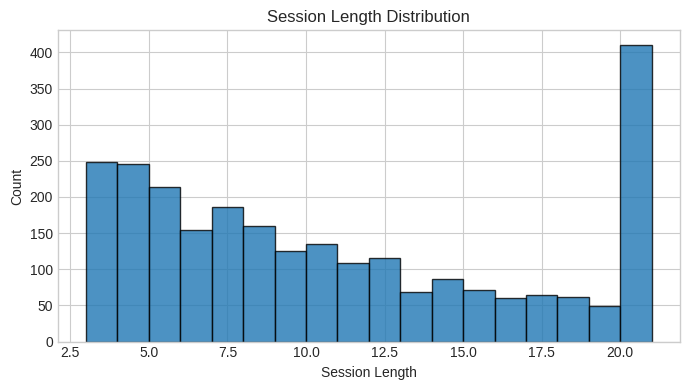

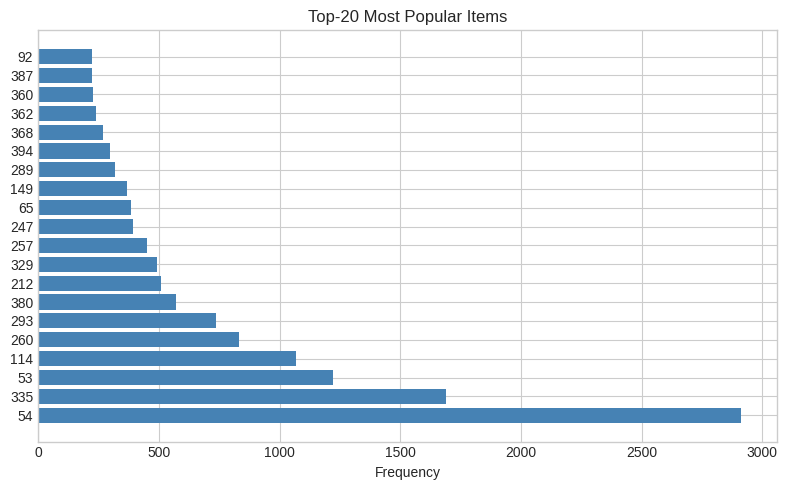

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Loading and analyzing data...")
with open("sessions.jsonl", "r", encoding="utf-8") as f:
    sessions = [json.loads(line) for line in f if line.strip()]

all_items = [item for s in sessions for item in s]
unique_items = set(all_items)
V = len(unique_items)

print(f"  Sessions: {len(sessions)}")
print(f"  Unique items: {V}")
print(f"  Average session length: {np.mean([len(s) for s in sessions]):.2f}")
print(f"  Sessions with duplicates: {sum(1 for s in sessions if len(s)!=len(set(s)))} ({sum(1 for s in sessions if len(s)!=len(set(s)))/len(sessions)*100:.1f}%)")

# session length histogram
lengths = [len(s) for s in sessions]
plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=range(min(lengths), max(lengths)+2), edgecolor='black', alpha=0.8)
plt.title("Session Length Distribution")
plt.xlabel("Session Length")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# top-20 frequencies
item_freq = Counter(all_items)
top_20 = item_freq.most_common(20)
plt.figure(figsize=(8, 5))
plt.barh(range(len(top_20)), [f for _, f in reversed(top_20)], color='steelblue')
plt.yticks(range(len(top_20)), [str(i) for i, _ in reversed(top_20)])
plt.title("Top-20 Most Popular Items")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Train/test split

In [14]:
print("Train/Test split...")
def prepare_train_test(sessions):
    train_pairs = []
    test_samples = []
    for s in sessions:
        if len(s) < 2:
            continue
        test_samples.append((s[:-1], s[-1]))
        for i in range(len(s) - 1):
            train_pairs.append((s[i], s[i+1]))
    return train_pairs, test_samples

train_pairs, test_samples = prepare_train_test(sessions)
print(f"  Train samples: {len(train_pairs)}")
print(f"  Test samples: {len(test_samples)}\n")

Train/Test split...
  Train samples: 24278
  Test samples: 2565



# Граф переходов

In [15]:
print("Building transition graph...")
def build_transition_graph(pairs, alpha=1e-6, vocab_size=V):
    out_cnt = Counter(src for src, _ in pairs)
    pair_cnt = Counter(pairs)
    graph = defaultdict(dict)
    for (s, d), c in pair_cnt.items():
        graph[s][d] = (c + alpha) / (out_cnt[s] + alpha * vocab_size)
    return dict(graph)

graph_1st = build_transition_graph(train_pairs)
print(f"  Vertexes of graph: {len(graph_1st)}")

# нормализованная
pop_counter = Counter(dst for _, dst in train_pairs)
total = sum(pop_counter.values())
global_pop = {item: cnt / total for item, cnt in pop_counter.items()}
print("  Global popularity calculated.\n")

Building transition graph...
  Vertexes of graph: 400
  Global popularity calculated.



# Рекомендательная модель

In [16]:
print("Recommendation model...")
def predict(history, graph, global_pop, k=10, pop_boost=0.05, exclude_seen=True):
    seen = set(history) if exclude_seen else set()
    scores = defaultdict(float)
    last = history[-1]

    # персонализация
    if last in graph:
        for nxt, prob in graph[last].items():
            if nxt not in seen:
                scores[nxt] += prob

    # глобальная популярность (для ничьих)
    if not scores:  # товар впервые в датасете
        return [item for item, _ in sorted(global_pop.items(),
                                           key=lambda x: x[1], reverse=True)[:k]]

    for item, pop_prob in global_pop.items():
        if item not in seen:
            scores[item] += pop_boost * pop_prob

    return [item for item, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]]

Recommendation model...


# Оценка качества

In [17]:
print("Evaluating the quality of a model using Hit@10...")
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), "recommendations and true_items lenght must be equal"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

true_items = [true for _, true in test_samples]

# бейзлайн
baseline_top10 = [item for item, _ in sorted(pop_counter.items(), key=lambda x: x[1], reverse=True)[:10]]
baseline_preds = [baseline_top10 for _ in test_samples]
baseline_hit = hit_at_k(baseline_preds, true_items, k=10)
print(f"Hit@10 (Baseline 'Popular'): {baseline_hit:.4f} ({baseline_hit*100:.2f}%)")

# модель
model_preds = [predict(h, graph_1st, global_pop, k=10) for h, _ in test_samples]
model_hit = hit_at_k(model_preds, true_items, k=10)
print(f"Hit@10 (Recommendation model):      {model_hit:.4f} ({model_hit*100:.2f}%)")
print(f"Growth: +{(model_hit - baseline_hit)*100:.2f}")

assert all(len(p) == 10 for p in model_preds), "Error: the prediction must contain exactly 10 items"

Evaluating the quality of a model using Hit@10...
Hit@10 (Baseline 'Popular'): 0.3840 (38.40%)
Hit@10 (Recommendation model):      0.5029 (50.29%)
Growth: +11.89
